## OLS With Dummy Variables using Statsmodels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.sandbox.regression.predstd import wls_prediction_std

np.random.seed(42)

In [4]:
nsample = 50
groups = np.zeros(nsample, int)
groups[20:40] = 1
groups[40:] = 2
dummy = pd.get_dummies(groups, dtype=int).values
x = np.linspace(0, 20, nsample)
X = np.column_stack((x, dummy[:, 1:]))
X = sm.add_constant(X, prepend=False)
beta = [1., 3, -3, 10]
y_true = np.dot(X, beta)
e = np.random.normal(size=nsample)
y = y_true + e

In [6]:
groups

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2])

In [7]:
dummy

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1]])

In [8]:
res = sm.OLS(y, X).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     704.8
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.93e-38
Time:                        18:06:53   Log-Likelihood:                -63.417
No. Observations:                  50   AIC:                             134.8
Df Residuals:                      46   BIC:                             142.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.9827      0.058     16.810      0.000       0.865       1.100
x2             3.0755      0.555      5.540      0.000       1.958       4.193
x3            -2.9948      0.905     -3.311      0.002      -4.816      -1.174
const         10.1591      0.303     33.566      0.000       9.550      10.768
==============================================================================
Omnibus:                        5.000   Durbin-Watson:                   2.209
Prob(Omnibus):                  0.082   Jarque-Bera (JB):                3.852
Skew:                          -0.585   Prob(JB):                        0.146
Kurtosis:                       3.692   Cond. No.                         96.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
def plot_compare(res):
    prstd, iv_l, iv_u = wls_prediction_std(res)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x, y, 'o', label='data')
    ax.plot(x, y_true, 'b-', label=True)
    ax.plot(x, res.fittedvalues, 'r--', label='OLS')
    ax.plot(x, iv_u, 'g--', label='Error')
    ax.plot(x, iv_l, 'g--')
    ax.legend(loc='best')
    plt.show()

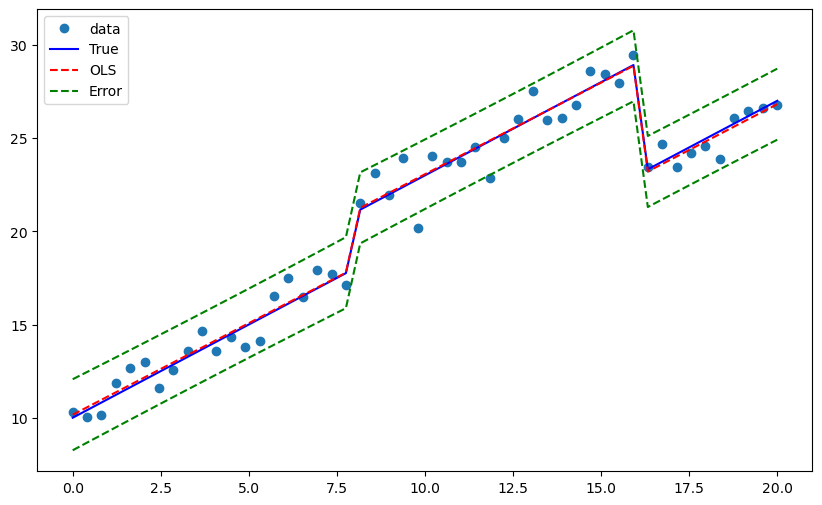

In [11]:
plot_compare(res)